In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$. $\newline$
This section is based off Theorem 2.6 of the paper.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
import mc

In [28]:
# We first define the constants
p_1 = 1/np.sqrt(2)
p_2 = 0
p_3 = 0.7
N = 100
p_rational_small = 0.35
p_irrational_small = 1/np.sqrt(8)
iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.

To estimate the optimal $m_1$ and $m_2$ we solve the equation

In [17]:
# try all combinations lol
def find_opt_int(N, p):
    L = int(np.floor(N**(1/3)))
    minimum = 10000
    min_m1, min_m2 = -1000, -1000
    for m_1 in range(-2*L, 2*L, 1):
        for m_2 in range(-2*L, 2*L, 1):
            if m_1 == 0 and m_2 == 0:
                continue
            diophan = np.absolute(p*m_1 + (1-p)*m_2)
            if diophan < minimum:
                minimum = diophan
                min_m1 = m_1
                min_m2 = m_2
    return min_m1, min_m2

In [18]:
m_1_irrational, m_2_irrational = find_opt_int(N, p_1)
m_1_small, m_2_small = find_opt_int(N, p_irrational_small)

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d \in \mathbb{Z}$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

In [19]:
def compute_delta_paper(p, m_1, m_2):
    print(p)
    all_deltas = np.zeros((number_deltas, iteration_count))

    for j in range(number_deltas):
        # we want X_0 to be sampled from the stationary distribution, so we randomly draw initial x and y
        # this is how to simulate the stationary distribution!!!
        curr_x = np.random.randint(0, N)
        curr_y = np.random.randint(0, N)
        val_sin = 0
        val_cos = 0

        for i in range(iteration_count):
            # take a step, then compute f
            curr_x, curr_y = mc.take_step(curr_x, curr_y, p, N)
            val_sin += np.sin(2*np.pi*(m_1*curr_x + m_2*curr_y + 1)/N)
            val_cos += np.cos(2*np.pi*(m_1*curr_x + m_2*curr_y + 1)/N)
            # compute empirical average of f after drawing i samples
            f_sum = val_sin**2 + val_cos**2 
            all_deltas[j, i] = f_sum/(i+1)**2

    delta_n = np.sqrt(np.mean(all_deltas, axis=0))
    return delta_n

Note that we at first wondered what $X_0 \sim \mu$ meant in terms of simulation, and then realized that it meant that at every run, we randomly sample $(x_0, y_0) \sim \mathcal{U}[1,\dots,N]$ instead of starting from a fixed position for every run of the $\Delta_n$.

In [20]:
delta_n_1 = compute_delta_paper(p_1, m_1_irrational, m_2_irrational) # sqrt
delta_n_3 = compute_delta_paper(p_3, 3, -7) # rational

0.7071067811865475
0.7


Now we plot $\Delta_n$ for all the different transition probabilities

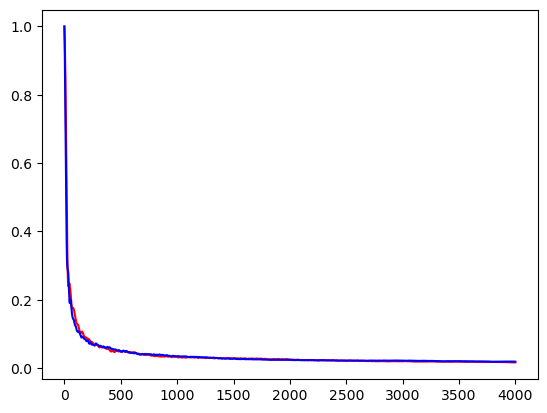

In [21]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="rational")
#plt.plot(range(iteration_count), [np.sqrt(0.2 * N**(4/3)/n) for n in range(1, iteration_count+1)], c="b", label="relaxation time")

We now estimate $\tau$. We do that by finding a constant such that $\tau \geq \frac{n\Delta_n^2}{4}, \forall n \geq 1$

In [22]:
tau_irrational = mc.compute_tau(delta_n_1)
tau_irrational

np.float64(1.8072833651363385)

In [23]:
tau_rational = mc.compute_tau(delta_n_3)
tau_rational

np.float64(1.2318161104110592)

Now we plot the different $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

/var/folders/22/_dymvqsd4tgfb0zzj_kpnj340000gn/T/ipykernel_2157/3988238463.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]


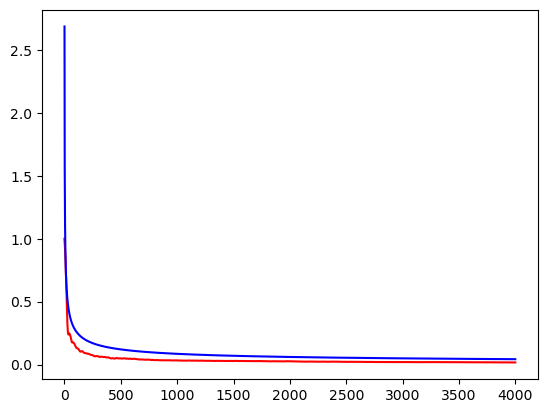

In [24]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')

/var/folders/22/_dymvqsd4tgfb0zzj_kpnj340000gn/T/ipykernel_2157/3522009561.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]


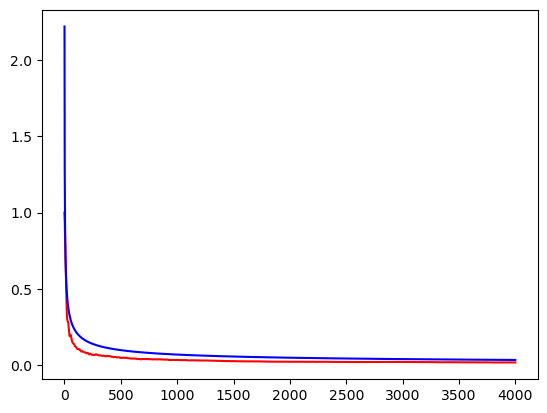

In [25]:
plt.plot(range(iteration_count), delta_n_3, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')

The $\Delta_n$ and $\tau$ computed above were found for $p_\text{rational} = 0.7$ and $p_\text{irrational} = \frac{1}{\sqrt 2}$. $\newline$ 
To observe if the constants scale with probabilities and if the convergence time of $\Delta_n$ is affected heavily by the transition probabilities, we now compute the same values for $p_\text{rational} = 0.35$ and $p_\text{irrational} = \frac{1}{\sqrt 8}$. $\newline$
We set $m_1 = -34, m_2 = 1$.

In [29]:
delta_n_irrational = compute_delta_paper(p_irrational_small, m_1_small, m_2_small) 
delta_n_rational = compute_delta_paper(p_rational_small, -34, 1) 

0.35355339059327373
0.35


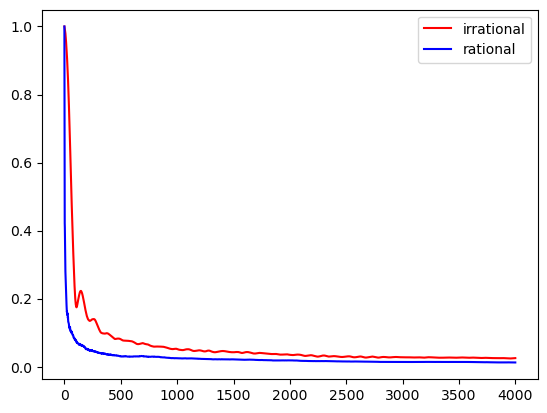

In [ ]:
plt.plot(range(iteration_count), delta_n_irrational, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_rational, c="b", label="rational")
plt.legend()

In [32]:
tau_small_irrational = mc.compute_tau(delta_n_irrational)
tau_small_rational = mc.compute_tau(delta_n_rational)
print("Irrational tau: ", tau_small_irrational)
print("Rational tau: ", tau_small_rational)

Irrational tau:  5.926577811170531
Rational tau:  0.1973914285345694


We now compute the exact value of $\tau$.
We begin by computing the respective transition matrices $P_{rational}$ and $P_{irrational}$. For each matrix, respectively compute $L = I-P$ and then the second smallest singular value $\gamma$. As in the paper, we define the relaxation time of the chain by $\tau = \frac{1}{\gamma}$.

We tried to compute $\tau$ by directly creating a transition matrix and computing all the singular values but that did not work out very well because the transition matrix is $O(N^4)$ in storage relative to its input, and the algorithm to compute SVD values is $O(N^3)$ in its input, so all in all we would be looking at an $O(N^{12})$ time algorithm which, for N=100 already, is... huge.

So we used sparse matrices and scipy svds magic to make everything work, which took a bit of optimization work.

In [13]:
### helper methods
# to go from and back to matrix indices based on a loop that goes through each element of the nodes once
def decode_index(idx):
    return idx % N, idx//N

def encode_index(x, y):
    return x + N*y

# construct the sparse matrices
def transition_positions(N, p):
    right_positions = []
    up_positions = []
    # going through every single node, and for each one adding the probability it goes right or up
    for node in range(N**2):
        x_1, y_1 = decode_index(node)
        x_2 = (x_1 + 1) % N
        y_2 = (y_1 + 1) % N

        right_node = encode_index(x_2, y_1)
        up_node = encode_index(x_1, y_2)

        right_positions.append((node, right_node))
        up_positions.append((node, up_node))

    # creating right, up, and identity sparse matrices to not kill my ram
    # data vector
    right_data = np.array([p]*len(right_positions))
    up_data = np.array([1-p]*len(up_positions))
    # data = np.concatenate((right_ps, up_ps), axis=None) 

    # separated the matrices into 3 to make debugging easier
    right_rows = np.array([k[0] for k in right_positions])
    right_cols = np.array([k[1] for k in right_positions])

    up_rows = np.array([k[0] for k in up_positions])
    up_cols = np.array([k[1] for k in up_positions])
    csr_right = csr_matrix((right_data, (right_rows, right_cols)), shape=(N**2,N**2))
    csr_up = csr_matrix((up_data, (up_rows, up_cols)), shape=(N**2,N**2))

    return csr_right, csr_up

# returns a matrix's second smallest singular value
def generator_sv(generator_matrix):
    u, s_min, vt = svds(generator_matrix, k=2, which="SM")
    abs_max = np.max(np.abs(s_min))
    return abs_max

# use helper functions above to do everything at once
def compute_tau(N, p):
    csr_right, csr_up = transition_positions(N, p)
    ones = np.ones(N**2)
    csr_identity = csr_matrix((ones, (range(N**2), range(N**2))))

    generator_matrix = csr_identity - (csr_right + csr_up)

    return 1/generator_sv(generator_matrix)

In [14]:
# computations 
irrational_tau = compute_tau(N, p_1)
rational_tau = compute_tau(N, p_3) 

In [67]:
irrational_tau

np.float64(117.14753456684554)

In [68]:
rational_tau

np.float64(135.57565743649224)

Now we simulate the value of $\tau$ as N grows for both $p=\frac{1}{\sqrt{2}}$ and $p = \frac{1}{2}$, in order to show whether there is a difference in curve smoothness to show different orders of magnitudes for each case.

In [18]:
N_values = range(20, 100)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(compute_tau(N, rational_p))
    irrational_tau_list.append(compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

tau number  20  finished computing
tau number  21  finished computing
tau number  22  finished computing
tau number  23  finished computing
tau number  24  finished computing
tau number  25  finished computing
tau number  26  finished computing
tau number  27  finished computing
tau number  28  finished computing
tau number  29  finished computing
tau number  30  finished computing
tau number  31  finished computing
tau number  32  finished computing
tau number  33  finished computing
tau number  34  finished computing
tau number  35  finished computing
tau number  36  finished computing
tau number  37  finished computing
tau number  38  finished computing
tau number  39  finished computing
tau number  40  finished computing
tau number  41  finished computing
tau number  42  finished computing
tau number  43  finished computing
tau number  44  finished computing
tau number  45  finished computing
tau number  46  finished computing
tau number  47  finished computing
tau number  48  fini

Text(0, 0.5, 'tau')

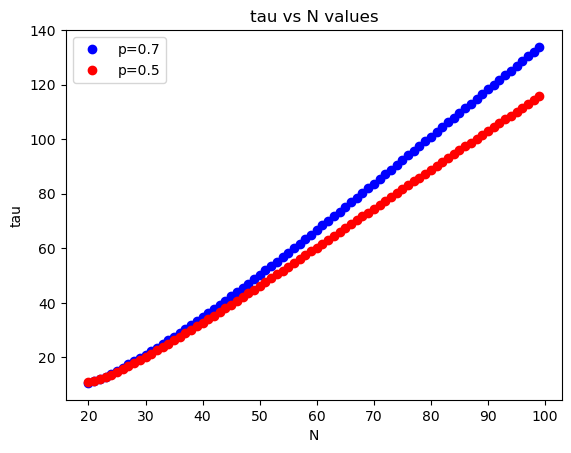

In [19]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")

In [20]:
N_values = range(101, 150)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(compute_tau(N, rational_p))
    irrational_tau_list.append(compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

tau number  101  finished computing
tau number  102  finished computing
tau number  103  finished computing
tau number  104  finished computing
tau number  105  finished computing
tau number  106  finished computing
tau number  107  finished computing
tau number  108  finished computing
tau number  109  finished computing
tau number  110  finished computing
tau number  111  finished computing
tau number  112  finished computing
tau number  113  finished computing
tau number  114  finished computing
tau number  115  finished computing
tau number  116  finished computing
tau number  117  finished computing
tau number  118  finished computing
tau number  119  finished computing
tau number  120  finished computing
tau number  121  finished computing
tau number  122  finished computing
tau number  123  finished computing
tau number  124  finished computing
tau number  125  finished computing
tau number  126  finished computing
tau number  127  finished computing
tau number  128  finished co

Text(0, 0.5, 'tau')

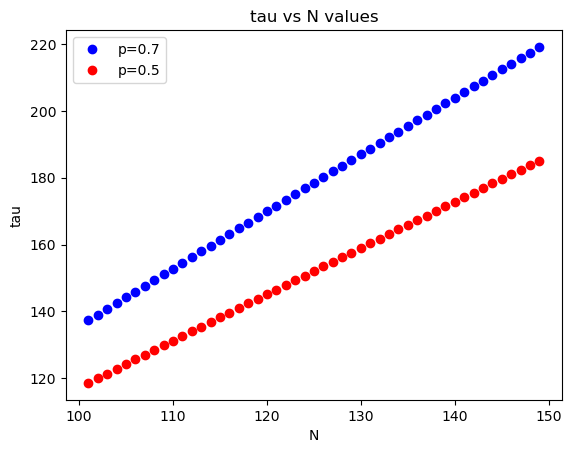

In [21]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")